Example sequences:
B A Z Y X X X Z -> label 0 (1 means A before B)
Z A Z X Z B Y X -> label 1 (1 means A before B)
A X X Z Z X Z B -> label 1 (1 means A before B)
Z Z Z A Y B X Y -> label 1 (1 means A before B)
X X Z Y A Y B Y -> label 1 (1 means A before B)

[none] Epoch 1/10 - loss: 0.6944 - val_acc: 0.5075
[none] Epoch 2/10 - loss: 0.6935 - val_acc: 0.4738
[none] Epoch 3/10 - loss: 0.6930 - val_acc: 0.4850
[none] Epoch 4/10 - loss: 0.6932 - val_acc: 0.4800
[none] Epoch 5/10 - loss: 0.6935 - val_acc: 0.4750
[none] Epoch 6/10 - loss: 0.6933 - val_acc: 0.4738
[none] Epoch 7/10 - loss: 0.6930 - val_acc: 0.4888
[none] Epoch 8/10 - loss: 0.6930 - val_acc: 0.4750
[none] Epoch 9/10 - loss: 0.6929 - val_acc: 0.4700
[none] Epoch 10/10 - loss: 0.6923 - val_acc: 0.4750

[sinusoidal] Epoch 1/10 - loss: 0.6945 - val_acc: 0.7913
[sinusoidal] Epoch 2/10 - loss: 0.5520 - val_acc: 0.9313
[sinusoidal] Epoch 3/10 - loss: 0.0604 - val_acc: 1.0000
[sinusoidal] Epoch 4/10 - loss: 0.0024 - val_acc: 1.0000


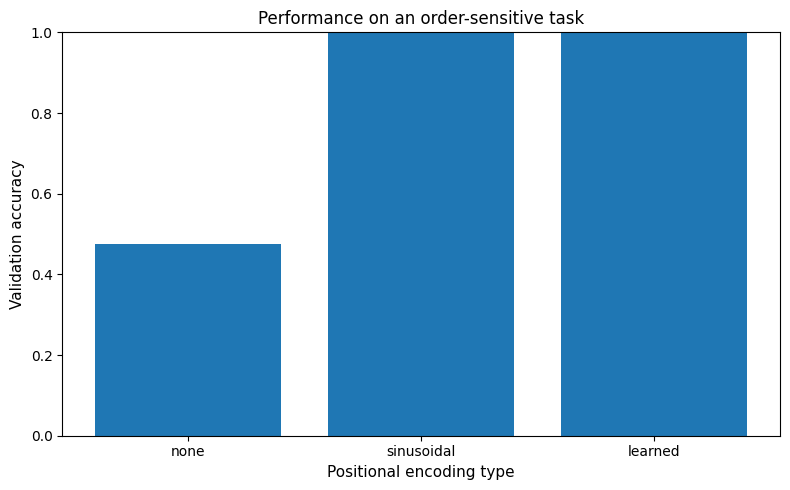


Final accuracies:
none: 0.4750
sinusoidal: 1.0000
learned: 1.0000


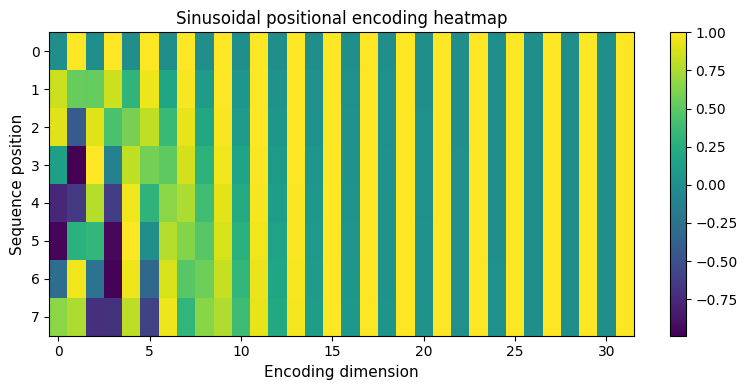

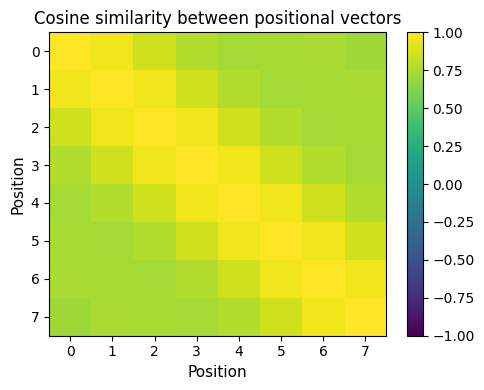

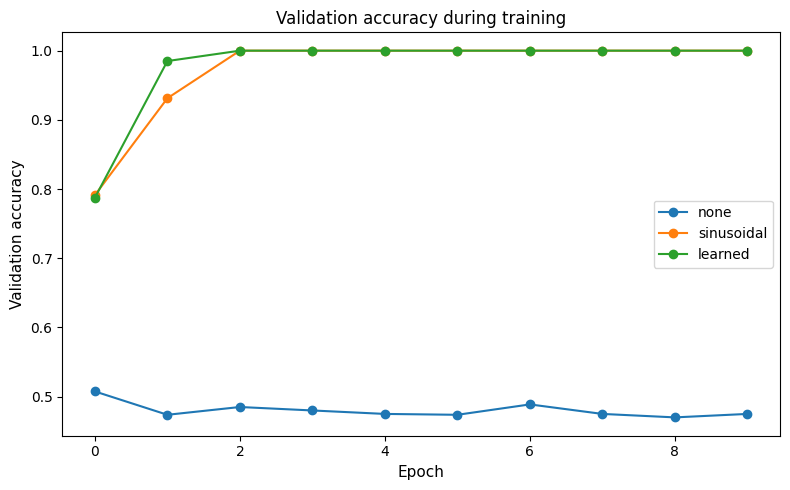

In [1]:
# ============================================================
# Positional Encoding in Transformers:
# How Sequence Order Is Represented Without Recurrence
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Plot settings
# -----------------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# ============================================================
# 1. Toy dataset
# ============================================================
# Task:
# Given a sequence, predict whether token A appears before token B.
# This makes order essential.
#
# Label = 1 if A appears before B
# Label = 0 if B appears before A
#
# Tokens:
# PAD=0, A=1, B=2, X=3, Y=4, Z=5
# ============================================================

VOCAB = {"PAD": 0, "A": 1, "B": 2, "X": 3, "Y": 4, "Z": 5}
ID2TOK = {v: k for k, v in VOCAB.items()}

SEQ_LEN = 8
VOCAB_SIZE = len(VOCAB)

def decode_sequence(seq):
    return " ".join(ID2TOK[int(x)] for x in seq)

def generate_example(seq_len=SEQ_LEN):
    """
    Generate one sequence.
    Exactly one A and one B are placed in random positions.
    Remaining positions are distractors.
    """
    seq = [VOCAB["X"]] * seq_len
    pos_a, pos_b = random.sample(range(seq_len), 2)
    seq[pos_a] = VOCAB["A"]
    seq[pos_b] = VOCAB["B"]

    for i in range(seq_len):
        if i not in [pos_a, pos_b]:
            seq[i] = random.choice([VOCAB["X"], VOCAB["Y"], VOCAB["Z"]])

    label = 1 if pos_a < pos_b else 0
    return seq, label

class OrderDataset(Dataset):
    def __init__(self, n_samples, seq_len=SEQ_LEN):
        self.samples = [generate_example(seq_len) for _ in range(n_samples)]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, label = self.samples[idx]
        return torch.tensor(seq, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Show a few examples
print("Example sequences:")
for _ in range(5):
    seq, label = generate_example()
    print(f"{decode_sequence(seq)} -> label {label} (1 means A before B)")

# ============================================================
# 2. Positional encodings
# ============================================================

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # shape [1, max_len, d_model]

    def forward(self, x):
        # x shape: [batch, seq_len, d_model]
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class LearnedPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        return x + self.pos_embedding(positions)

# ============================================================
# 3. Tiny self-attention classifier
# ============================================================
# Simple by design:
# - token embedding
# - optional positional encoding
# - one MultiheadAttention layer
# - mean pooling
# - classifier
# ============================================================

class TinyAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=4, pos_type="none", max_len=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_type = pos_type

        if pos_type == "sinusoidal":
            self.pos_encoder = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        elif pos_type == "learned":
            self.pos_encoder = LearnedPositionalEncoding(d_model, max_len=max_len)
        else:
            self.pos_encoder = None

        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 2)
        )

    def forward(self, x):
        emb = self.embedding(x)  # [B, T, D]

        if self.pos_encoder is not None:
            emb = self.pos_encoder(emb)

        attn_out, _ = self.attn(emb, emb, emb)
        out = self.norm(attn_out + emb)

        pooled = out.mean(dim=1)  # simple mean pooling
        logits = self.classifier(pooled)
        return logits

# ============================================================
# 4. Training and evaluation
# ============================================================

def train_model(pos_type, train_samples=3000, val_samples=800, epochs=10, batch_size=64, lr=1e-3):
    train_ds = OrderDataset(train_samples)
    val_ds = OrderDataset(val_samples)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = TinyAttentionClassifier(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        pos_type=pos_type,
        max_len=SEQ_LEN
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        val_acc = evaluate_model(model, val_loader)

        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)

        print(f"[{pos_type}] Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - val_acc: {val_acc:.4f}")

    return model, history

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(x_batch)
        preds = logits.argmax(dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return correct / total

# ============================================================
# 5. Train all three settings
# ============================================================

results = {}
histories = {}

for pos_type in ["none", "sinusoidal", "learned"]:
    print("\n" + "=" * 60)
    model, history = train_model(pos_type=pos_type)
    results[pos_type] = model
    histories[pos_type] = history

# ============================================================
# 6. Plot 1: Accuracy comparison
# ============================================================

final_accs = {k: histories[k]["val_acc"][-1] for k in histories}

plt.figure()
plt.bar(final_accs.keys(), final_accs.values())
plt.ylim(0, 1.0)
plt.xlabel("Positional encoding type")
plt.ylabel("Validation accuracy")
plt.title("Performance on an order-sensitive task")
plt.tight_layout()
plt.show()

print("\nFinal accuracies:")
for k, v in final_accs.items():
    print(f"{k}: {v:.4f}")

# ============================================================
# 7. Plot 2: Sinusoidal positional encoding heatmap
# ============================================================

d_model = 32
sin_pe = SinusoidalPositionalEncoding(d_model=d_model, max_len=SEQ_LEN)
pe_matrix = sin_pe.pe[0, :SEQ_LEN, :].cpu().numpy()

plt.figure(figsize=(8, 4))
plt.imshow(pe_matrix, aspect="auto")
plt.colorbar()
plt.xlabel("Encoding dimension")
plt.ylabel("Sequence position")
plt.title("Sinusoidal positional encoding heatmap")
plt.tight_layout()
plt.show()

# ============================================================
# 8. Plot 3: Similarity structure of sinusoidal encodings
# ============================================================

def cosine_similarity_matrix(x):
    x_norm = x / np.linalg.norm(x, axis=1, keepdims=True)
    return x_norm @ x_norm.T

sim_matrix = cosine_similarity_matrix(pe_matrix)

plt.figure(figsize=(5, 4))
plt.imshow(sim_matrix, vmin=-1, vmax=1, aspect="auto")
plt.colorbar()
plt.xlabel("Position")
plt.ylabel("Position")
plt.title("Cosine similarity between positional vectors")
plt.tight_layout()
plt.show()

# ============================================================
# 9. Optional: Training curves
# ============================================================

plt.figure()
for pos_type in histories:
    plt.plot(histories[pos_type]["val_acc"], marker="o", label=pos_type)
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy during training")
plt.legend()
plt.tight_layout()
plt.show()